## Group 5 | Assignment 1 | Road checker: Assessing Bicycle Lane Quality Using Smartphone Sensor Data

Group members
- Su Acar (2475901)
- Vikram Chandrasekaran (2542544)
- Henrique DaSilva Couto (2463334)

## Dataset extraction and pre-checks

Downloads the raw sensor data folder from Google Drive into `downloads/` (installing `gdown` if needed). Skip re-running this cell if the data is already present locally.

In [ ]:
#Extract data from Google Drive ONLY IF it is not in the data/ folder yet
# Download gdown-6.2.0

try:
    
    import gdown
    import shutil
except ImportError:
    import subprocess
    import sys

folder_url = "https://drive.google.com/drive/folders/1DpgvoIUkZJ55P85hu4zdvwaJ9wdvKUn8"
output_dir = "downloads/"

gdown.download_folder(
    url=folder_url,
    output=output_dir,
    quiet=False,
    use_cookies=False
)

shutil.move("./downloads/road-checker-data/", "./data/downloads/",)

import os
os.rmdir("./downloads/")

Retrieving folder contents


Processing file 1LjG-YvJ0_-crJ_qguCD6vTaIS7suEzKY 2026-09-21_14-52-44.zip
Processing file 1STx4KSDMpBQG9c3vFepD7ptN_WxPadCb HC-annotations-19min-2026-09-19_09-02-09.zip
Processing file 1dedsRtbjrC08VoKBfL3tzH3Qiz0Qe_ZQ HC-annotations-19min-2026-09-19_10-44-41.zip
Processing file 1VoPjmYsZjDH0ZHblIgNGz6dCDtDko76P HC-bumpy-2min-2026-09-19_08-54-37.zip
Processing file 1BmuNQSm5XJqa2u8SONxFBIlusN17dCYs Raw001_Smooth.zip
Processing file 1LwAA1_tM7cu86V67fnOpAoZKqd9XEIK_ Raw002_Smooth.zip
Processing file 1DR5dgrvtVgNP1pgypWaGbuJesFwX8pRg Raw003_Smooth.zip
Processing file 1zUpRJBDDcfZtXXNhkNio93RWI5RQthBn Raw004_Bumpy.zip
Processing file 1o5Xv3ty8Nm1a2pqGt04Srxo6mVzzveji Raw005_Bumpy.zip
Processing file 181pGS5JSw2CyzuaaKngpdsrrgk_vEMoR Raw006_Bumpy.zip
Processing file 1g8PrFEYCTKI-olneZjBxgRXkO_BmDcfY Raw007_Smooth.zip
Processing file 1FkoZFyMlittvcMbLZObdbryoUSjbt9H- Raw008_Smooth.zip
Processing file 1ATJNFdbcKLB6GWh7VZjEa2_RG4-4Q5kF Raw009_Smooth.zip
Processing file 10gi219MerRfki0ZR6XnTbI

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1LjG-YvJ0_-crJ_qguCD6vTaIS7suEzKY
To: /home/thesuacar/Desktop/DALM/road-checker/downloads/road-checker-data/2026-09-21_14-52-44.zip
100%|██████████| 2.61M/2.61M [00:00<00:00, 17.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1STx4KSDMpBQG9c3vFepD7ptN_WxPadCb
To: /home/thesuacar/Desktop/DALM/road-checker/downloads/road-checker-data/HC-annotations-19min-2026-09-19_09-02-09.zip
100%|██████████| 25.2M/25.2M [00:01<00:00, 23.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dedsRtbjrC08VoKBfL3tzH3Qiz0Qe_ZQ
To: /home/thesuacar/Desktop/DALM/road-checker/downloads/road-checker-data/HC-annotations-19min-2026-09-19_10-44-41.zip
100%|██████████| 24.9M/24.9M [00:00<00:00, 25.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VoPjmYsZjDH0ZHblIgNGz6dCDtDko76P
To: /home/thesuacar/Desktop/DALM/road-checker/downloads/

## Calculating frequencies of all data - sensor wise

### Unzip all recordings

In [2]:
import glob
import zipfile
zip_files = glob.glob("data/downloads/Raw*.zip")

for file_path in zip_files:
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        folder_name = (zip_ref.filename).split('/')[-1][:-4]
        zip_ref.extractall(f'data/extracted/{folder_name}')

### Sampling frequency per sensor across recordings

For each recording, the sampling frequency (Hz) of each sensor is estimated from the mean interval between consecutive `seconds_elapsed` timestamps

The plots below show for each sensor how its sampling frequency varies across recordings (sorted alphabetically by recording name)

This is useful for spotting recordings with inconsistencies and find out which device is causing these

In [3]:
import numpy as np
import pandas as pd
import json

base_path_extracted = "data/extracted"
data_file_mapping = {
    "accelerometer_calibrated" : "Accelerometer.csv",
    # "accelerometer_uncalibrated" : "AccelerometerUncalibrated.csv",
    "gravity" : "Gravity.csv",
    "gyroscope_calibrated": "Gyroscope.csv",
    # "gyroscope_uncalibrated": "GyroscopeUncalibrated.csv"  
}

csv_files = glob.glob("data/extracted/*/*.csv")

recording_sensor_freq_mapping = {}
missing_file_flag = []

for file_path in csv_files: 
    recording_name = file_path.split('/')[-2] + ''
    recording_sensor_freq_mapping[recording_name] = {}
    for sensor, file_name in data_file_mapping.items():
        try:
            sensor_seconds_elapsed_array = pd.read_csv(f"{base_path_extracted }/{recording_name}/{file_name}")['seconds_elapsed']
            dt = sensor_seconds_elapsed_array.diff().mean()
            sensor_sampling_frequency_hz = 1 / dt
            recording_sensor_freq_mapping[recording_name][sensor] = sensor_sampling_frequency_hz
        except FileNotFoundError as e:
            missing_file_flag.append(str(e))
            continue

if len(missing_file_flag):
    print('\n'.join(missing_file_flag))
else:
    print('All recordings are intact with all required sensor data')

print('-------------------------------')
print("Values are in Hz")
print(json.dumps(recording_sensor_freq_mapping, indent = 4, default = str))

All recordings are intact with all required sensor data
-------------------------------
Values are in Hz
{
    "Raw028_Bumpy": {
        "accelerometer_calibrated": 99.59255113952631,
        "gravity": 99.59255113952631,
        "gyroscope_calibrated": 99.59255113952631
    },
    "Raw005_Bumpy": {
        "accelerometer_calibrated": 99.61714167655259,
        "gravity": 99.61714167655259,
        "gyroscope_calibrated": 99.61714167655259
    },
    "Raw004_Bumpy": {
        "accelerometer_calibrated": 99.60044540428339,
        "gravity": 99.60044540428339,
        "gyroscope_calibrated": 99.60044540428339
    },
    "Raw003_Smooth": {
        "accelerometer_calibrated": 62.05149618179637,
        "gravity": 61.99060168112729,
        "gyroscope_calibrated": 61.99060168112729
    },
    "Raw010_Bumpy": {
        "accelerometer_calibrated": 99.59786331054303,
        "gravity": 99.59786331054303,
        "gyroscope_calibrated": 99.59786331054303
    },
    "Raw019_Smooth": {
        "

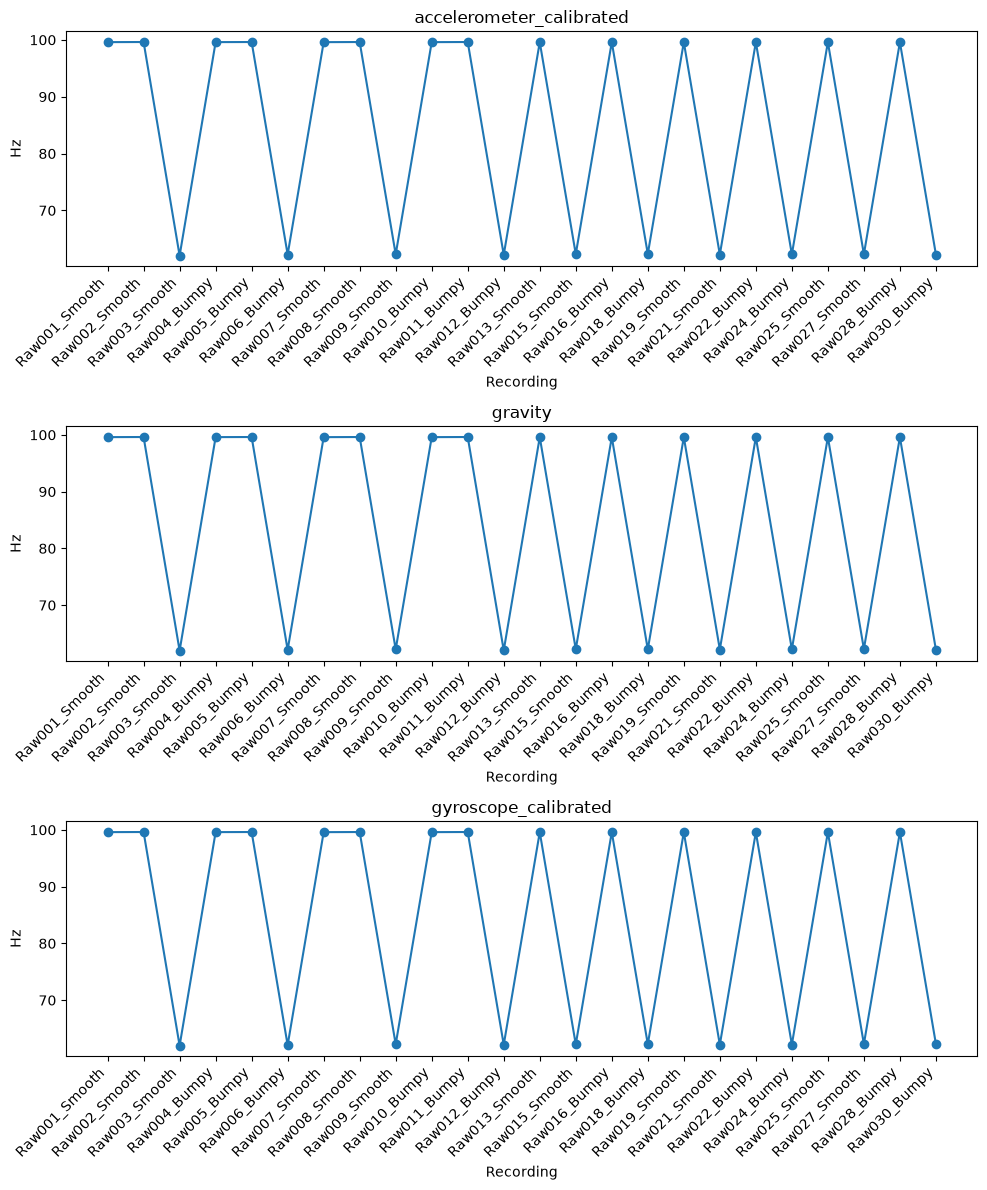

In [4]:
import matplotlib.pyplot as plt

recording_sensor_freq_df = pd.DataFrame(recording_sensor_freq_mapping).T.sort_index()

sensors = recording_sensor_freq_df.columns
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 4 * len(sensors)))

for ax, sensor in zip(axes, sensors):
    ax.plot(recording_sensor_freq_df.index, recording_sensor_freq_df[sensor], marker='o')
    ax.set_ylabel("Hz")
    ax.set_title(sensor)
    ax.set_xlabel("Recording")
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.show()

## Filter recordings not having ~100Hz frequency to maintain consistency

In [5]:
delta_threshold = 1  # Hz

filtered_recording_sensor_freq_df = recording_sensor_freq_df[((recording_sensor_freq_df - 100).abs() < delta_threshold).all(axis=1)]

filtered_recording_names = list(filtered_recording_sensor_freq_df.index)


## Consolidate all sensors into one CSV file

Build one consolidated dataframe with all sensor data for every recording, indexed by `(recording_id, time)` so each row is a single timestamp for one recording.

In [6]:
sensor_data_all_recording_consolidated_df = pd.DataFrame()
axis_list = ['x','y', 'z']

for recording_name in filtered_recording_names:
    # Recording folder names look like "Raw001_Smooth" 
    # split into id and terrain label
    recording_id = recording_name.split('_')[0]
    recording_terrain = recording_name.split('_')[1]

    # Holds this recording's sensors merged side-by-side (columns), built up sensor by sensor
    # aka globally 
    single_recording_consolidated_df = pd.DataFrame()

    for sensor_name, file_name in data_file_mapping.items():
        csv_file = f"data/extracted/{recording_name}/{file_name}"
        temp_df = pd.read_csv(csv_file)

        # Prefix x/y/z with the sensor name so columns stay unique once we merge sensors together
        # e.g. "x" -> "accelerometer_calibrated_x"
        temp_df.rename(columns = {axis: f"{sensor_name}_{axis}" for axis in axis_list}, inplace=True)

        # Index every row with this recording's id, and its timestamp
        recording_ids = [recording_id] * len(temp_df)
        multi_index = pd.MultiIndex.from_arrays([recording_ids, temp_df["time"]],names=["recording_id", "time"],)
        temp_df.set_index(multi_index, inplace=True)

        # We will concatenate at the end once after the merging operations
        seconds_elapsed_column = temp_df['seconds_elapsed']

        # Keep only this sensor's x/y/z axis data
        # This is because seconds_elapsed and time column is redundant in each CSV, and has been indexed in the previous step
        temp_df = temp_df[[f"{sensor_name}_{axis}" for axis in axis_list]]  

        # Add this sensor's columns to the single_recording df, matching rows by the index (recording_id, time)
        single_recording_consolidated_df = pd.concat([single_recording_consolidated_df, temp_df], axis = 1)

    # Add the road terrain label (Bumpy/Smooth) to every row of this single recording
    # Add new column seconds_elapsed from the backup
    single_recording_consolidated_df['recording_terrain'] = [recording_terrain] * len(single_recording_consolidated_df)
    single_recording_consolidated_df['seconds_elapsed'] = seconds_elapsed_column

    # Merge(row-wise) the single_recording df with the globally managed df
    sensor_data_all_recording_consolidated_df = pd.concat([sensor_data_all_recording_consolidated_df, single_recording_consolidated_df])   

sensor_data_all_recording_consolidated_df.to_csv('data/sensor_data_all_recording_consolidated_df.csv')

In [7]:
sensor_data_all_recording_consolidated_df.loc[('Raw001', 1788710950665228500)]

accelerometer_calibrated_x    0.217445
accelerometer_calibrated_y   -0.014899
accelerometer_calibrated_z    0.495448
gravity_x                    -1.659353
gravity_y                     7.101885
gravity_z                     6.555925
gyroscope_calibrated_x        0.170799
gyroscope_calibrated_y       -0.164239
gyroscope_calibrated_z        0.066929
recording_terrain               Smooth
seconds_elapsed               0.170229
Name: (Raw001, 1788710950665228500), dtype: object